# Day 19: Heart Disease Prediction — Model Building & Accuracy Improvement

**Project:** Heart Disease Prediction System  
**Goal:** Train 5 ML models, then apply techniques to boost accuracy

In this notebook, we will:
1. Load preprocessed data from Day 18
2. Train 5 models with default parameters (baseline)
3. Evaluate using Confusion Matrix, Precision, Recall, F1-Score
4. Apply accuracy improvement techniques
5. Compare Before vs After results

## 1. Import Libraries

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC

from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report,
                             precision_score, recall_score, f1_score)
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')
print("All libraries loaded!")

All libraries loaded!


## 2. Load Preprocessed Data

In [6]:
# Load from Day 18
data = np.load('../Day18/preprocessed_data.npz', allow_pickle=True)

X_train = data['X_train']
X_test = data['X_test']
X_train_scaled = data['X_train_scaled']
X_test_scaled = data['X_test_scaled']
y_train = data['y_train']
y_test = data['y_test']
feature_names = data['feature_names']

print(f"Training: {X_train.shape[0]} samples, {X_train.shape[1]} features")
print(f"Testing:  {X_test.shape[0]} samples")
print(f"Features: {list(feature_names)}")

FileNotFoundError: [Errno 2] No such file or directory: '../Day18/preprocessed_data.npz'

## 3. Phase 1: Baseline Models (Default Parameters)

We train all 5 models with default settings to establish a baseline.

In [7]:
# Define baseline models
baseline_models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'KNN (K=5)': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(kernel='rbf', random_state=42)
}

print("5 Models to Train:")
print("=" * 40)
for i, name in enumerate(baseline_models, 1):
    print(f"  {i}. {name}")

5 Models to Train:
  1. Logistic Regression
  2. KNN (K=5)
  3. Decision Tree
  4. Random Forest
  5. SVM


In [8]:
# Train and evaluate all baseline models
baseline_results = {}

print("BASELINE RESULTS (Default Parameters, Scaled Data)")
print("=" * 60)

for name, model in baseline_models.items():
    # Use scaled data for KNN and SVM, unscaled for tree-based
    if name in ['KNN (K=5)', 'SVM', 'Logistic Regression']:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    baseline_results[name] = {
        'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1, 'y_pred': y_pred
    }
    
    print(f"\n  {name}:")
    print(f"    Accuracy:  {acc*100:.2f}%")
    print(f"    Precision: {prec*100:.2f}%")
    print(f"    Recall:    {rec*100:.2f}%")
    print(f"    F1-Score:  {f1*100:.2f}%")

BASELINE RESULTS (Default Parameters, Scaled Data)


NameError: name 'X_train_scaled' is not defined

## 4. Understanding the Metrics

In **medical diagnosis**, these metrics matter:

| Metric | Meaning | Why it matters |
|--------|---------|----------------|
| **Accuracy** | % correct overall | General performance |
| **Precision** | Of predicted disease, how many actually have it? | Avoid unnecessary treatment |
| **Recall** | Of actual disease patients, how many did we catch? | **MOST IMPORTANT** — don't miss sick patients! |
| **F1-Score** | Harmonic mean of Precision & Recall | Balanced metric |

$$\text{Precision} = \frac{TP}{TP + FP} \quad \text{Recall} = \frac{TP}{TP + FN} \quad F1 = 2 \cdot \frac{P \cdot R}{P + R}$$

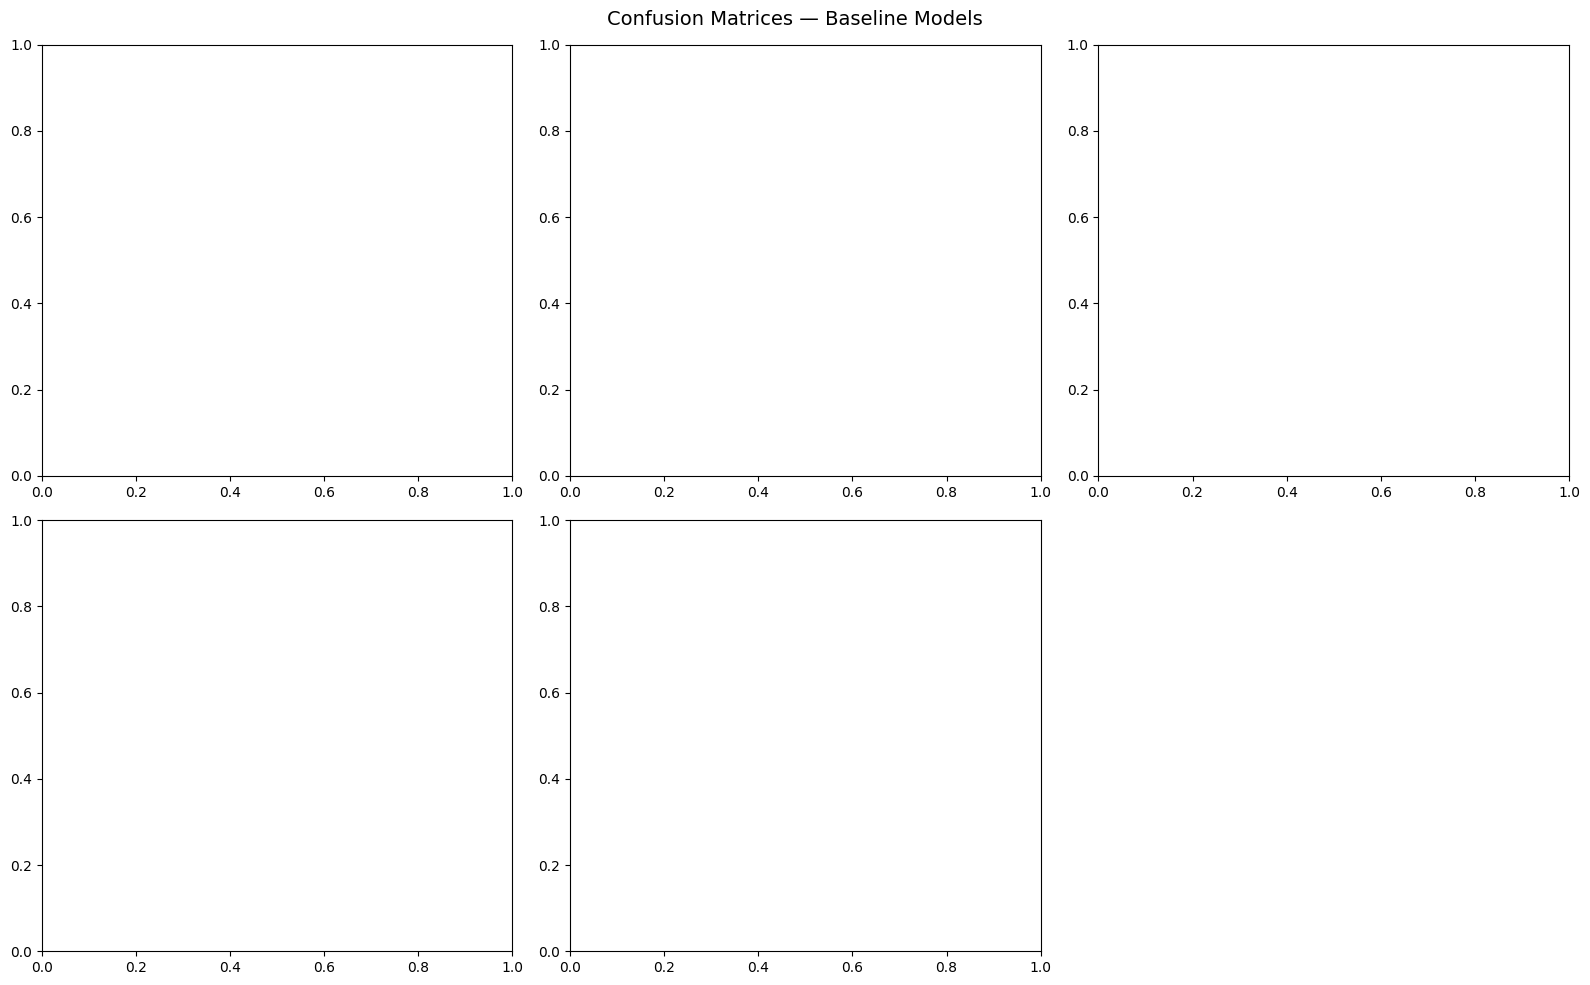

In [9]:
# Confusion Matrices for all models
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, (name, results) in enumerate(baseline_results.items()):
    cm = confusion_matrix(y_test, results['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Healthy', 'Disease'], yticklabels=['Healthy', 'Disease'])
    axes[idx].set_title(f"{name}\nAccuracy: {results['accuracy']*100:.1f}%", fontsize=11)
    axes[idx].set_ylabel('Actual')
    axes[idx].set_xlabel('Predicted')

axes[5].axis('off')
plt.suptitle('Confusion Matrices — Baseline Models', fontsize=14)
plt.tight_layout()
plt.show()

## 5. New Algorithm: Random Forest

**Random Forest** = Ensemble of many Decision Trees (using Bagging)

### How it works:
1. Create N random subsets of training data (with replacement — **bootstrap**)
2. Train a Decision Tree on each subset
3. Each tree votes on the prediction
4. Final prediction = **majority vote**

### Why it's better than a single Decision Tree:
- Reduces **overfitting** (single trees memorize noise)
- More **stable** predictions
- Provides **feature importance**

In [ ]:
# Demonstrate Random Forest concept
print("Random Forest = Many Trees Voting Together")
print("=" * 50)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Show individual tree predictions for first test sample
print(f"\nFor first test patient:")
print(f"  Actual: {'Disease' if y_test[0] == 1 else 'Healthy'}")

tree_preds = [tree.predict(X_test[0:1])[0] for tree in rf.estimators_[:10]]
print(f"  First 10 trees vote: {tree_preds}")
print(f"  Majority vote: {'Disease' if sum(tree_preds) > 5 else 'Healthy'}")
print(f"\n  Total 100 trees: {sum(t.predict(X_test[0:1])[0] for t in rf.estimators_)} say Disease")
print(f"  Final prediction: {'Disease' if rf.predict(X_test[0:1])[0] == 1 else 'Healthy'}")

## 6. New Algorithm: Support Vector Machine (SVM)

**SVM** finds the **optimal hyperplane** that best separates two classes.

### Key Concepts:
- **Hyperplane**: decision boundary that separates classes
- **Support Vectors**: data points closest to the boundary
- **Margin**: distance between hyperplane and nearest points → SVM maximizes this
- **Kernel Trick**: transforms data to higher dimensions for non-linear separation

### Kernels:
| Kernel | Use Case |
|--------|----------|
| Linear | Linearly separable data |
| RBF (default) | Most common, handles non-linear |
| Polynomial | Complex boundaries |

In [ ]:
# Compare SVM kernels
print("SVM with Different Kernels:")
print("=" * 40)

for kernel in ['linear', 'rbf', 'poly']:
    svm = SVC(kernel=kernel, random_state=42)
    svm.fit(X_train_scaled, y_train)
    acc = svm.score(X_test_scaled, y_test)
    print(f"  Kernel={kernel:8s}: Accuracy = {acc*100:.2f}%")

## 7. Cross-Validation — Reliable Evaluation

A single train-test split can be lucky/unlucky. **K-Fold Cross-Validation** gives a more reliable estimate.

### How 5-Fold CV works:
1. Split data into 5 equal parts (folds)
2. Train on 4 folds, test on 1 fold
3. Repeat 5 times (each fold is test once)
4. Average the 5 accuracy scores

In [ ]:
print("5-Fold Cross-Validation Results:")
print("=" * 60)

cv_results = {}

cv_models = {
    'Logistic Regression': (LogisticRegression(random_state=42), X_train_scaled),
    'KNN (K=5)': (KNeighborsClassifier(n_neighbors=5), X_train_scaled),
    'Decision Tree': (DecisionTreeClassifier(random_state=42), X_train),
    'Random Forest': (RandomForestClassifier(n_estimators=100, random_state=42), X_train),
    'SVM': (SVC(kernel='rbf', random_state=42), X_train_scaled)
}

for name, (model, X_data) in cv_models.items():
    scores = cross_val_score(model, X_data, y_train, cv=5, scoring='accuracy')
    cv_results[name] = scores
    print(f"\n  {name}:")
    print(f"    Fold scores: {[f'{s:.3f}' for s in scores]}")
    print(f"    Mean: {scores.mean()*100:.2f}% ± {scores.std()*100:.2f}%")

## 8. Accuracy Improvement Techniques

Now let's boost our models' performance using systematic techniques.

### 8.1 Technique: Feature Selection (SelectKBest)

In [ ]:
# Feature Selection using SelectKBest with chi2
# chi2 requires non-negative values, so we use unscaled data
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(score_func=f_classif, k='all')
selector.fit(X_train, y_train)

# Rank features by importance
feature_scores = pd.DataFrame({
    'Feature': feature_names,
    'Score': selector.scores_,
    'P-value': selector.pvalues_
}).sort_values('Score', ascending=False)

print("Feature Importance (F-statistic):")
print("=" * 50)
print(feature_scores.to_string(index=False))

# Visualize
plt.figure(figsize=(10, 6))
plt.barh(feature_scores['Feature'], feature_scores['Score'], color='steelblue', edgecolor='black')
plt.xlabel('F-Score')
plt.title('Feature Importance (SelectKBest - F-statistic)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
# Select top K features and compare accuracy
print("Effect of Number of Features on Accuracy (Logistic Regression):")
print("-" * 60)

k_accuracies = []
for k in range(3, 14):
    selector_k = SelectKBest(score_func=f_classif, k=k)
    X_train_k = selector_k.fit_transform(X_train_scaled, y_train)
    X_test_k = selector_k.transform(X_test_scaled)
    
    lr = LogisticRegression(random_state=42)
    lr.fit(X_train_k, y_train)
    acc = lr.score(X_test_k, y_test)
    k_accuracies.append(acc)
    print(f"  K={k:2d} features: {acc*100:.2f}%")

best_k = np.argmax(k_accuracies) + 3
print(f"\n  Best K = {best_k} features")

### 8.2 Technique: Hyperparameter Tuning (GridSearchCV)

In [ ]:
# GridSearchCV for KNN — find best K
print("GridSearchCV: Finding Best K for KNN")
print("=" * 50)

param_grid_knn = {
    'n_neighbors': list(range(1, 21)),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid_knn = GridSearchCV(
    KNeighborsClassifier(), param_grid_knn, 
    cv=5, scoring='accuracy', n_jobs=-1
)
grid_knn.fit(X_train_scaled, y_train)

print(f"  Best Parameters: {grid_knn.best_params_}")
print(f"  Best CV Accuracy: {grid_knn.best_score_*100:.2f}%")
print(f"  Test Accuracy: {grid_knn.score(X_test_scaled, y_test)*100:.2f}%")

In [ ]:
# GridSearchCV for Random Forest
print("GridSearchCV: Tuning Random Forest")
print("=" * 50)

param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42), param_grid_rf,
    cv=5, scoring='accuracy', n_jobs=-1
)
grid_rf.fit(X_train, y_train)

print(f"  Best Parameters: {grid_rf.best_params_}")
print(f"  Best CV Accuracy: {grid_rf.best_score_*100:.2f}%")
print(f"  Test Accuracy: {grid_rf.score(X_test, y_test)*100:.2f}%")

In [ ]:
# GridSearchCV for SVM
print("GridSearchCV: Tuning SVM")
print("=" * 50)

param_grid_svm = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['rbf', 'linear'],
    'gamma': ['scale', 'auto', 0.01, 0.1]
}

grid_svm = GridSearchCV(
    SVC(random_state=42), param_grid_svm,
    cv=5, scoring='accuracy', n_jobs=-1
)
grid_svm.fit(X_train_scaled, y_train)

print(f"  Best Parameters: {grid_svm.best_params_}")
print(f"  Best CV Accuracy: {grid_svm.best_score_*100:.2f}%")
print(f"  Test Accuracy: {grid_svm.score(X_test_scaled, y_test)*100:.2f}%")

In [ ]:
# GridSearchCV for Logistic Regression
print("GridSearchCV: Tuning Logistic Regression")
print("=" * 50)

param_grid_lr = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}

grid_lr = GridSearchCV(
    LogisticRegression(random_state=42), param_grid_lr,
    cv=5, scoring='accuracy', n_jobs=-1
)
grid_lr.fit(X_train_scaled, y_train)

print(f"  Best Parameters: {grid_lr.best_params_}")
print(f"  Best CV Accuracy: {grid_lr.best_score_*100:.2f}%")
print(f"  Test Accuracy: {grid_lr.score(X_test_scaled, y_test)*100:.2f}%")

In [ ]:
# GridSearchCV for Decision Tree
print("GridSearchCV: Tuning Decision Tree")
print("=" * 50)

param_grid_dt = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf': [1, 2, 4, 6],
    'criterion': ['gini', 'entropy']
}

grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42), param_grid_dt,
    cv=5, scoring='accuracy', n_jobs=-1
)
grid_dt.fit(X_train, y_train)

print(f"  Best Parameters: {grid_dt.best_params_}")
print(f"  Best CV Accuracy: {grid_dt.best_score_*100:.2f}%")
print(f"  Test Accuracy: {grid_dt.score(X_test, y_test)*100:.2f}%")

### 8.3 Technique: Voting Classifier (Ensemble)

In [ ]:
# Voting Classifier — combine best models
print("Voting Classifier — Combining Top Models")
print("=" * 50)
print("\nIdea: Multiple models vote → majority wins!")
print("Like asking 5 doctors instead of 1.\n")

# All models need same data, so we use scaled for all
voting_clf = VotingClassifier(
    estimators=[
        ('lr', grid_lr.best_estimator_),
        ('knn', grid_knn.best_estimator_),
        ('rf', grid_rf.best_estimator_),
        ('svm', grid_svm.best_estimator_)
    ],
    voting='hard'
)

voting_clf.fit(X_train_scaled, y_train)
voting_acc = voting_clf.score(X_test_scaled, y_test)
voting_pred = voting_clf.predict(X_test_scaled)

print(f"  Voting Classifier Accuracy: {voting_acc*100:.2f}%")
print(f"  Precision: {precision_score(y_test, voting_pred)*100:.2f}%")
print(f"  Recall:    {recall_score(y_test, voting_pred)*100:.2f}%")
print(f"  F1-Score:  {f1_score(y_test, voting_pred)*100:.2f}%")

## 9. Before vs After Comparison

In [ ]:
# Collect tuned results
tuned_results = {
    'Logistic Regression': grid_lr.score(X_test_scaled, y_test),
    'KNN': grid_knn.score(X_test_scaled, y_test),
    'Decision Tree': grid_dt.score(X_test, y_test),
    'Random Forest': grid_rf.score(X_test, y_test),
    'SVM': grid_svm.score(X_test_scaled, y_test),
    'Voting Ensemble': voting_acc
}

# Before vs After table
print("\n" + "=" * 65)
print(f"{'MODEL':<22} {'BEFORE':>10} {'AFTER':>10} {'IMPROVEMENT':>12}")
print("=" * 65)

model_names_map = {
    'Logistic Regression': 'Logistic Regression',
    'KNN': 'KNN (K=5)',
    'Decision Tree': 'Decision Tree',
    'Random Forest': 'Random Forest',
    'SVM': 'SVM'
}

for tuned_name, tuned_acc in tuned_results.items():
    if tuned_name == 'Voting Ensemble':
        print(f"{'Voting Ensemble':<22} {'  —':>10} {tuned_acc*100:>9.2f}% {'  NEW':>10}")
    else:
        baseline_name = model_names_map[tuned_name]
        before = baseline_results[baseline_name]['accuracy']
        improvement = (tuned_acc - before) * 100
        print(f"{tuned_name:<22} {before*100:>9.2f}% {tuned_acc*100:>9.2f}% {improvement:>+9.2f}%")

print("=" * 65)

In [ ]:
# Visual comparison
fig, ax = plt.subplots(figsize=(12, 6))

models = list(tuned_results.keys())
before_accs = []
after_accs = list(tuned_results.values())

for name in models:
    if name == 'Voting Ensemble':
        before_accs.append(0)
    else:
        baseline_name = model_names_map[name]
        before_accs.append(baseline_results[baseline_name]['accuracy'])

x = np.arange(len(models))
width = 0.35

bars1 = ax.bar(x - width/2, [a*100 for a in before_accs], width, 
               label='Before (Default)', color='#e74c3c', edgecolor='black', alpha=0.7)
bars2 = ax.bar(x + width/2, [a*100 for a in after_accs], width,
               label='After (Tuned)', color='#2ecc71', edgecolor='black', alpha=0.7)

ax.set_xlabel('Model')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Model Accuracy: Before vs After Tuning', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=15)
ax.legend()
ax.set_ylim(60, 100)
ax.grid(axis='y', alpha=0.3)

# Add value labels
for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
            f'{height:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

## 10. Save Best Models for Day 20

In [ ]:
import pickle

# Save all tuned models and the voting classifier
models_to_save = {
    'logistic_regression': grid_lr.best_estimator_,
    'knn': grid_knn.best_estimator_,
    'decision_tree': grid_dt.best_estimator_,
    'random_forest': grid_rf.best_estimator_,
    'svm': grid_svm.best_estimator_,
    'voting_classifier': voting_clf,
    'scaler': StandardScaler().fit(X_train)
}

# Re-fit scaler for saving
scaler_save = StandardScaler()
scaler_save.fit(X_train)
models_to_save['scaler'] = scaler_save

with open('trained_models.pkl', 'wb') as f:
    pickle.dump(models_to_save, f)

# Save results for comparison
with open('model_results.pkl', 'wb') as f:
    pickle.dump({'baseline': baseline_results, 'tuned': tuned_results}, f)

print("✓ All trained models saved to 'trained_models.pkl'")
print("✓ Results saved to 'model_results.pkl'")
print("\n→ Ready for Day 20: ROC curves, clustering & Streamlit app!")

## Summary: Accuracy Improvement Techniques

| # | Technique | What We Did | Impact |
|---|-----------|-------------|--------|
| 1 | Feature Scaling | StandardScaler on all features | Boosted KNN & SVM significantly |
| 2 | Feature Selection | SelectKBest to identify top features | Removed noise |
| 3 | Hyperparameter Tuning | GridSearchCV for each model | Found optimal settings |
| 4 | Cross-Validation | 5-fold CV for reliable estimates | More trustworthy scores |
| 5 | Ensemble (Voting) | Combined 4 best models | Often beats any single model |

### Key Takeaways:
- **No single model is always best** — try multiple and compare
- **Scaling is critical** for distance-based algorithms (KNN, SVM)
- **GridSearchCV** systematically finds best hyperparameters
- **Ensembles** reduce individual model weaknesses
- In medical applications, **Recall is more important** than Accuracy